# Why Databases Exist

Alex Ronczewski  
2026-07-19

## Outline

### Prerequisites

-   Comfort with `pandas` and basic Python knowledge is recommended
-   You do **not** need any database or SQL background.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Describe where the datasets used in econometrics and machine
    learning actually come from, and why the world’s data lives in
    databases.
2.  Explain why shared files break down as a way to keep data:
    redundancy, update anomalies, and concurrent editing.
3.  Define **database**, **database management system (DBMS)**, and
    **SQL**, and state the advantages of a DBMS over regular files.
4.  Load a table into **SQLite** from a notebook and query it with
    `SELECT`, `WHERE`, and `ORDER BY`.
5.  Explain what it means that SQL is **declarative**.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 1. Before the CSV

Every notebook you have worked through in COMET or prAxIs starts the
same way: `pd.read_csv`, and a clean dataframe appears, but it was not
created out of nowhere. It was the final product of a pipeline somebody
built: data born in one place, stored under rules, extracted, shaped,
and finally handed to you. This stream is about everything that happens
before the CSV, because that is where most real data work happens.

Data is born in **operational systems**: the checkout that records a
sale, the payroll system that records your hours, the interview software
running a survey. Those systems write into databases, because they need
guarantees a file cannot give: never lose a row, never let two edits
collide, never accept an impossible value. Statistical agencies work the
same way; a release like Statistics Canada’s Labour Force Survey starts
as interview records in databases and passes through cleaning, coding,
and weighting steps before anything public appears. The tidy CSV at the
end is the visible tip of that process, and someone designed every step
behind it. That someone is doing **data engineering**!

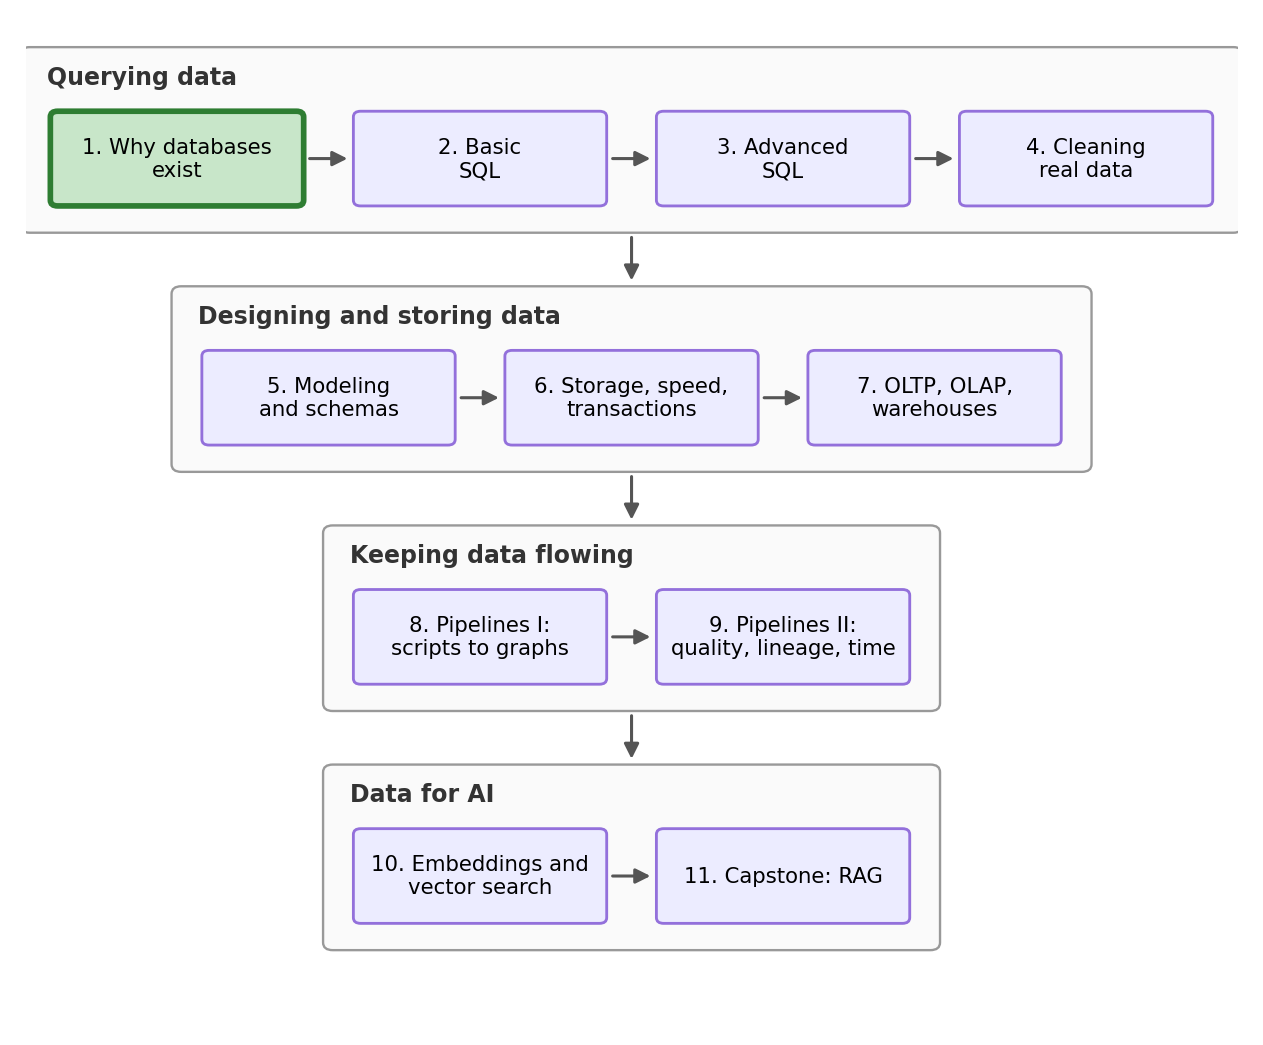

Machine learning uses the same foundation. The training corpus of a
large language model is the output of a pipeline that crawls the web,
filters and deduplicates it, and stores it in formats built for scale
(they appear in Notebook 6). A production recommender or fraud model is
retrained on features extracted, by queries, from operational databases.
A retrieval-augmented (RAG) chatbot is (in its simplest form) a database
attached to a model: the model’s answers are only as good as what the
data contains. This is an old observation in the field: the figure
below, from a well-known Google paper, shows how little of a real ML
system is the model itself, and how much is the data infrastructure
around it.

<figure>
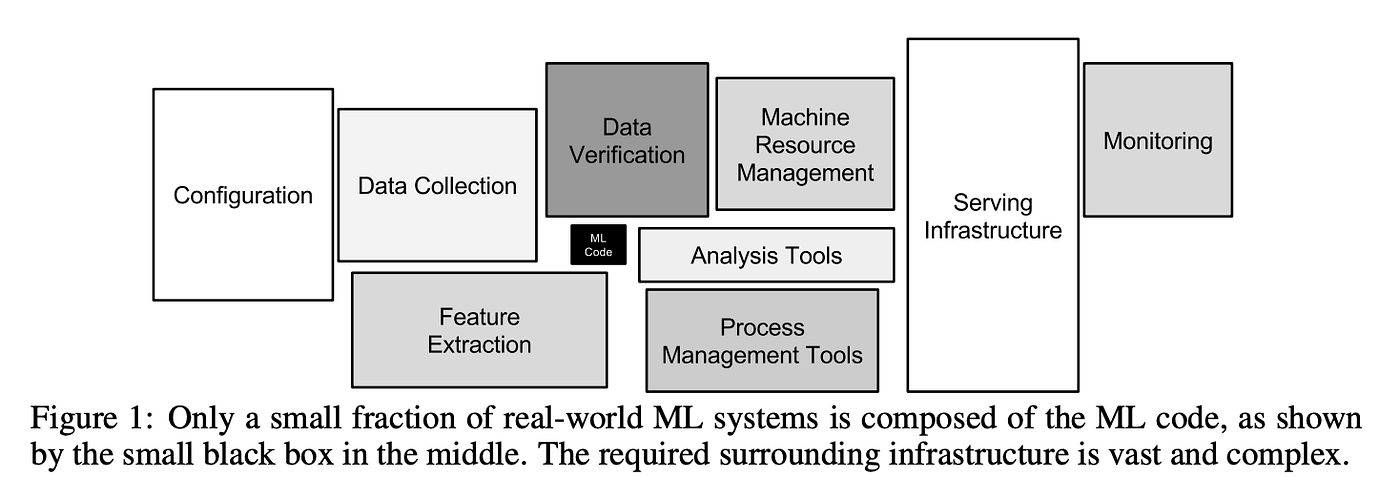
<figcaption aria-hidden="true">Figure 1 of Sculley et al. (2015),
“Hidden Technical Debt in Machine Learning Systems”. The small black box
is the ML code; everything around it is the subject of this
stream.</figcaption>
</figure>

There is also a more practical reason to learn this: employers ask for
it. SQL has sat for years near the top of the most-requested skills in
data analyst and data scientist job postings, often ahead of Python and
R. The gap between how often jobs ask for SQL and how few students
outside CS or statistics ever write any is the gap this stream will
fill. This material is endlessly applicable.

An aside (as you most likely have already thought of this): modern LLMs
write SQL quite well, but this does not invalidate the skill. Someone
still has to design what the tables mean, judge whether the generated
query answers the question actually asked, and catch the query that runs
error-free and returns the wrong thing. You cannot verify what you do
not understand, so these skills are becoming more valuable as
query-writing gets cheaper, the same way calculators made mathematical
judgment matter more, and arithmetic itself matter less.

## 2. Why a file is not enough

If databases did not exist, the natural way to keep a dataset would be a
file: a spreadsheet or a CSV. For a small dataset that one person
analyzes and throws away, that works fine, and it is how plenty of real
data is still kept. The trouble starts when data is shared, edited over
time, and expected to stay correct, because a file enforces nothing: it
is a sequence of characters, it accepts anything, and it stores every
mistake the same as the real information we are after. The failures that
follow are so common they have names:

| A typical failure                                                      | What it is called                                                                |
|------------------------------------|------------------------------------|
| The same person stored several times, under several spellings          | **Redundancy**, with no notion of identity to tie the copies together            |
| A fix appended as an extra row, with the wrong row left in place       | An **update anomaly**: changing a fact creates a second version of it            |
| A wage column that quietly switches from annual salary to hourly wages | **No enforced types or meaning**: a column is whatever anyone types into it      |
| `BC`, `B.C.`, `bc`, `Britsh Columbia` in one region column             | **No controlled categories**: free text where a fixed set of values was intended |
| Several people editing emailed copies of one spreadsheet               | A **concurrency** problem: simultaneous edits with no referee                    |

None of these ever produces an error message. A file loads correctly
with three spellings of one person just as it does with one, and the
damage surfaces only later, in analysis results, where it is expensive
to trace back, or, even worse, it never surfaces at all. Notebook 4
hands you a survey file with every one of these problems in it and
teaches you to repair it.

These failures reach the news regularly. In October 2020, nearly 16,000
positive COVID test results dropped out of England’s contact-tracing
system because the reporting pipeline moved through an aging Excel file
format whose row limit silently cut off every file that grew too long
(BBC News, 2020). The tests existed and the files loaded; the rows past
the limit simply were not in them, and thousands of exposed contacts
went untraced.

> **Think Deeper.** Your bank balance is a row in a database. Imagine it
> were a row in a spreadsheet emailed between branches: two deposits
> processed on two copies of the file, merged at the end of the day, and
> one of them simply vanishes. The reason that never happens is the
> piece of software this notebook is about.

## 3. The database and the DBMS

> **Three definitions**
>
> A **database** is a collection of data organized under explicit rules:
> what tables exist, what each column means and contains, and what
> counts as a valid entry.
>
> A **database management system (DBMS)** is the software that stores
> the data and enforces those rules, so that the mistakes from section 2
> never happen.
>
> **SQL** (Structured Query Language) is the standard language for
> asking a DBMS questions and giving it instructions.

A DBMS has value because it takes over exactly the jobs a shared
spreadsheet leaves to luck:

1.  **Structure.** Every table declares its columns and their types up
    front, and most database engines use those types to refuse values
    that do not fit, so a wage column which is meant to contain
    numerical entries can reject the text string `refused` outright. A
    change in what a column means has to become an explicit change in
    the structure of the database.
2.  **Integrity rules.** The database can enforce that every respondent
    has exactly one row, that a region must come from a fixed list (for
    example, US states), or that a wage must fall in a plausible range.
3.  **One copy, many users.** Everyone reads and writes the same single
    database, at the same time, and the DBMS handles the access so that
    edits are never lost.
4.  **Durability.** If the machine crashes mid-write, the database
    recovers to a consistent state instead of a half-saved file.
5.  **A query language.** Instead of every analyst writing their own
    cleaning-and-averaging script, everyone asks questions in the same
    language: SQL.

The kind of database we use in this stream is a **relational** database,
where data lives in tables: each row is one individual’s record, each
column is one property of the individual (wage, age, location, etc.),
and every row has the same columns.

### 3.1 SQLite

The DBMS we will use for most of this stream is **SQLite**. It is a
complete relational DBMS in a small library: it has no server or account
requirements, and the entire database lives in a single file. It is also
one of the most widely deployed databases in existence, running inside
phones, browsers, and applications on billions of devices.

The names you hear in industry, PostgreSQL, MySQL, SQL Server, and the
cloud warehouses, are DBMSs too. Most of them run as a **server** that
many users connect to over a network, which is how “one copy, many
users” scales to a whole company. They all function in SQL, so nearly
everything you learn on SQLite transfers directly.

## 4. A first database

Time to build one. The dataset for this stream is a wage survey: 1,000
respondents, one row each, with their age, education, province,
industry, hours, and hourly wage. It is simulated for the stream,
modelled on labour force surveys, and every later notebook builds on it.

> **Why simulated data?**
>
> The simulation is a deliberate choice we make in this stream, and
> later notebooks take ever greater advantage of it. A teaching dataset
> needs a truth we know and failures we control: Notebook 4 cleans a
> file whose every flaw was planted in advance, and Notebook 7 recovers
> wage premiums we wrote into the world ourselves. Real public wage
> microdata can do neither, because it is anonymized before release, and
> what anonymization strips out is exactly what this stream teaches.
> Where real data fits, we use it: Notebook 2’s province table carries
> the true legal minimum wages and populations, and the final two
> notebooks run entirely on real consumer complaints.

We load our simulated survey dataset into the notebook from a .csv:

In [2]:
survey = pd.read_csv("datasets/wage_survey.csv")
survey.head()

Loading it into SQLite takes two lines: connect, then write the
dataframe in as a table. The connection creates `wage_survey.db` in the
datasets folder, and that single file is the entire database. The number
the cell returns is the count of rows written.

In [3]:
conn = sqlite3.connect("datasets/wage_survey.db")
survey.to_sql("survey", conn, index=False, if_exists="replace")

1000

The table now has declared structure, which we can ask the database to
show us:

In [4]:
pd.read_sql("PRAGMA table_info(survey)", conn)[["name", "type"]]

Every column has a type: `INTEGER` for counts and codes, `REAL` for
wages and hours, `TEXT` for categories. This is the schema, the table’s
contract about what each column holds. In this notebook we inherit it
automatically from the dataframe; in Notebook 5 we will write schemas
ourselves and add the integrity rules that make the database refuse bad
data outright.

### 4.1 SELECT

Every question we ask a database in this stream is some elaboration of a
`SELECT` statement. The basic shape is `SELECT` *which columns* `FROM`
*which table*, and we run it with `pd.read_sql`, which sends the query
to SQLite and hands the result back as a dataframe:

In [5]:
pd.read_sql("SELECT respondent_id, age, education, province, hourly_wage FROM survey LIMIT 5", conn)

`LIMIT 5` caps the output, playing the role `.head()` plays in `pandas`.
Note what happened here: `pandas` did no work beyond displaying the
result. The database found the columns and rows and returned only them.

For the remainder of the stream we will not run queries through
`pd.read_sql`; Jupyter notebooks have a better way: the `jupysql`
extension adds a `%%sql` marker that turns an entire cell into SQL. We
set it up once, pointing it at our database file and asking for results
as dataframes:

In [6]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False
%config SqlMagic.feedback = 0
%sql sqlite:///datasets/wage_survey.db

From here on, every query cell in this stream is written this way: pure
SQL, one clause per line, the standard format you will find in
documentation, on practice sites, and in interviews. Here is the same
`SELECT` again in its new form:

In [7]:
%%sql
SELECT respondent_id, age, education, province, hourly_wage
FROM survey
LIMIT 5

### 4.2 WHERE

`WHERE` keeps the rows that satisfy a condition. Conditions can be
combined with `AND` and `OR`, and text values are compared against
strings in single quotes. Here is every respondent in British Columbia
earning 40 dollars an hour or more:

In [8]:
%%sql
SELECT respondent_id, industry, hourly_wage
FROM survey
WHERE province = 'British Columbia' AND hourly_wage >= 40

138 rows × 3 columns

The footer of the result counts 138 rows, and the condition we wanted,
`province = 'British Columbia'`, works with no guessing about spellings,
because the rules the data was collected under guarantee the table
contains exactly one spelling.

> **Your turn.** Write a query that returns the `respondent_id`,
> `industry`, and `weekly_hours` of every respondent in Alberta who
> works fewer than 30 hours a week. Start the cell with `%%sql`. If it
> is right, it returns 26 rows.

In [9]:
# your query here

Show / hide answer

``` sql
%%sql
SELECT respondent_id, industry, weekly_hours
FROM survey
WHERE province = 'Alberta' AND weekly_hours < 30
```

### 4.3 ORDER BY

`ORDER BY` sorts the result by a column, with `DESC` for descending. The
five highest earners in the survey:

In [10]:
%%sql
SELECT respondent_id, province, industry, education, hourly_wage
FROM survey
ORDER BY hourly_wage DESC
LIMIT 5

Technology and finance at the top, with university degrees, which is
what we would expect. The main point is how effortless and
human-readable the syntax is.

Anything the database returns is a dataframe, so it plugs straight into
the tools you already know. `jupysql`’s `<<` arrow stores a query’s
result in a Python variable, so the survey’s whole wage distribution is
one `SELECT` away:

In [11]:
%%sql all_wages <<
SELECT hourly_wage
FROM survey

And we can use Python visualization libraries like Matplotlib to graph
it.

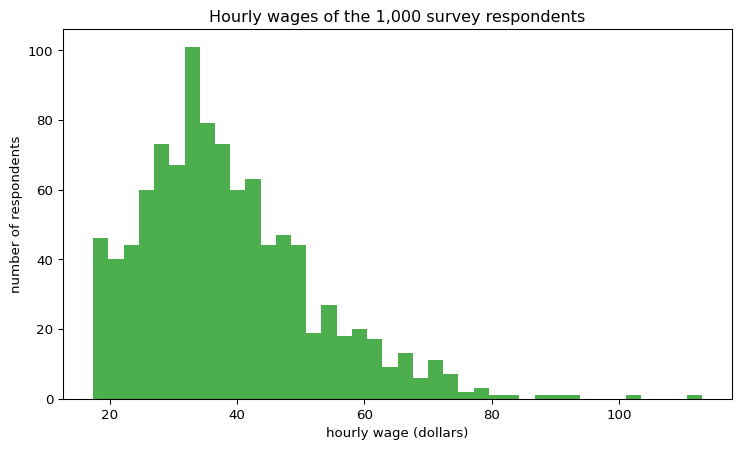

In [12]:
plt.figure(figsize=(9, 5))
plt.hist(all_wages["hourly_wage"], bins=40, color="tab:green", alpha=0.85)
plt.xlabel("hourly wage (dollars)")
plt.ylabel("number of respondents")
plt.title("Hourly wages of the 1,000 survey respondents")
plt.show()

> **SQL is declarative**
>
> In every query above we described the result we wanted, and never the
> steps to compute it. We did not write loops, did not decide what
> columns or rows to scan in which order, and did not manage memory; the
> DBMS chose how to execute each query, and it is extremely good at
> choosing. A language where you state *what* you want is called
> **declarative**. Most of the programming you know, Python/R included,
> is *imperative*: you spell out the steps. This division of labour, you
> declare, the engine executes, is a big part of why SQL has outlived
> every language fashion cycle since the 1970s.

> **Self-test**
>
> `survey.head()` at the top of this section and `SELECT ... LIMIT 5`
> produced similar five-row previews. What is different about how the
> two answers were made?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> `.head()` sliced a dataframe that Python was already holding fully in
> memory; `read_csv` had loaded all 1,000 rows before we asked for five.
> The `SELECT` sent a request to the database, and only the five rows
> and five columns asked for ever came back. With 1,000 rows the
> difference is invisible. With a hundred million rows, loading
> everything into memory stops being possible, and asking the database
> for only what you need is the way that keeps working. Notebook 6 dives
> deeper into this.
>
> </details>

## 5. The road ahead

This stream is eleven notebooks, in four arcs. Here is the map, which
reappears in each one so you always know where you are:

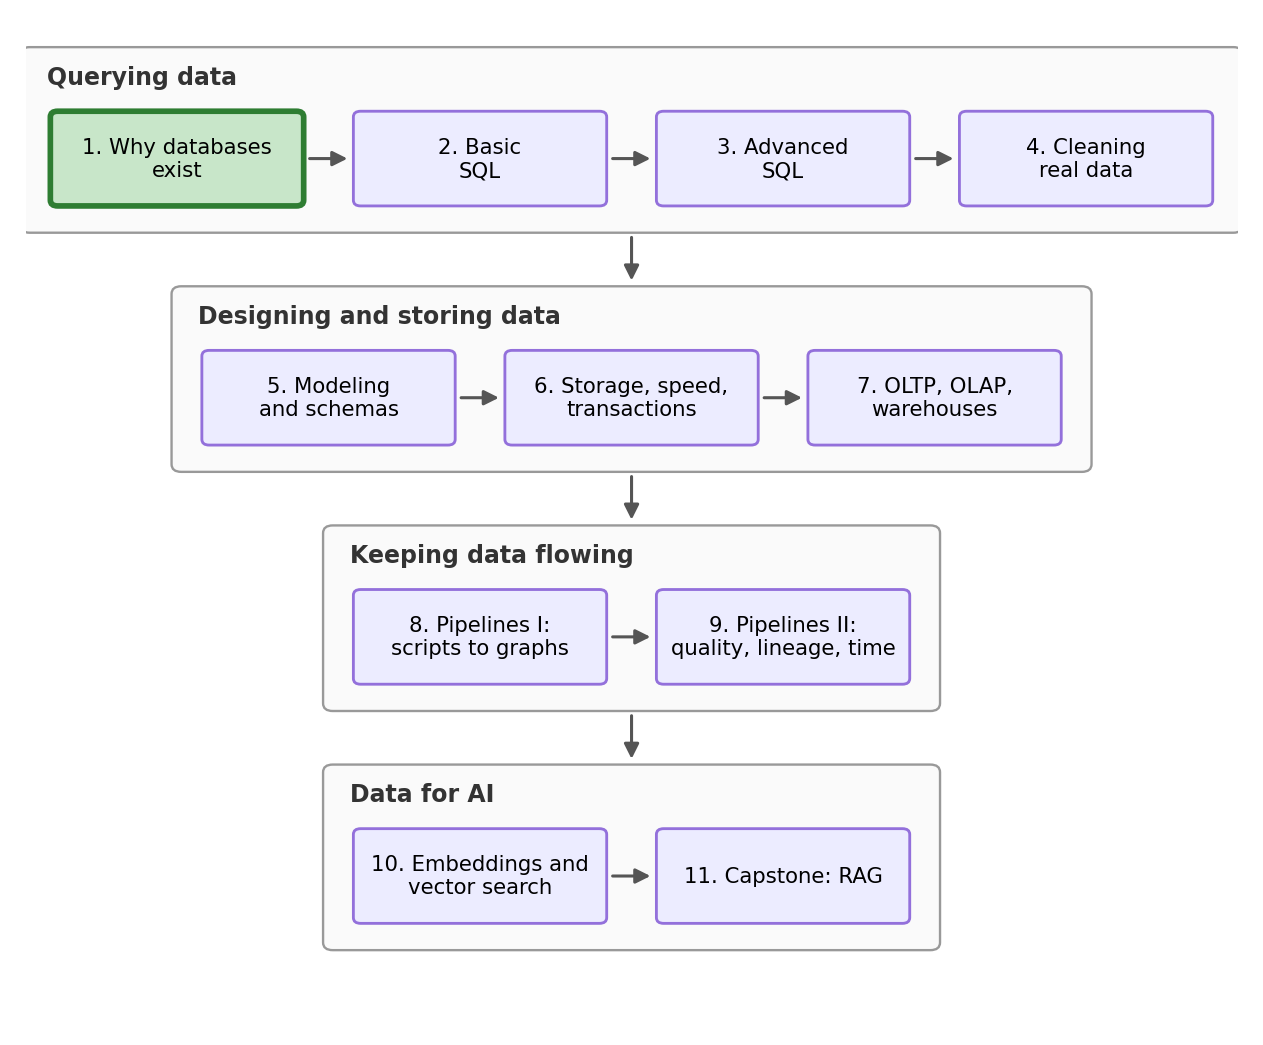

You are here, at **Notebook 1**. Each later notebook takes the wage
survey one step further:

-   **Notebook 2, Basic querying.** The core of SQL in a single
    `SELECT`: joins across tables and why they change row counts,
    `GROUP BY` and aggregates, `NULL` and its silent effects on
    averages, `CASE` logic, and a bunch of plausible-looking wrong
    queries for you to fix.
-   **Notebook 3, Advanced SQL.** Subqueries, CTEs, and views; window
    functions; inserting and updating data; and how to run SQL from
    Python safely, including what a SQL injection is.
-   **Notebook 4, Cleaning real data.** We get handed a hand-maintained
    survey file with every failure from section 2 in it, and clean it
    properly: entity resolution for respondents recorded under several
    spellings, string and date repair, outlier flags, imputation
    choices, and every fix as a reproducible script against immutable
    raw data.
-   **Notebook 5, Designing data.** Entity-relationship modelling,
    primary and foreign keys, constraints that make the database refuse
    bad rows, and normalization, connected to the tidy data idea you
    know from COMET or DSCI 100.
-   **Notebook 6, Storage, speed, and transactions.** ACID and
    deliberately crashing a database mid-write, indexes and reading
    query plans, row versus column storage with DuckDB benchmarks, and
    why Parquet beats CSV.
-   **Notebook 7, Two kinds of databases.** Transactional versus
    analytical workloads, star schemas, the ETL step between them,
    warehouses and lakes.
-   **Notebook 8, Pipelines I: scripts to graphs.** An update script
    dies halfway, and re-running it double-counts everything;
    idempotency, incremental loads, logging and retries, and pipelines
    as directed acyclic graphs you build, sabotage, and fix.
-   **Notebook 9, Pipelines II: quality, lineage, and time.** A new
    month of data arrives subtly broken and the pipeline runs green
    anyway; validation checks that halt bad loads, tracing what a bad
    file poisoned, a small scheduler, and backfills, which are the
    concepts industry tools like dbt and Airflow sell.
-   **Notebook 10, Databases for AI.** Embeddings as coordinates of
    meaning, similarity search as an `ORDER BY distance`, where semantic
    search beats exact matching and where it loses.
-   **Notebook 11, Capstone RAG.** Build a full retrieval-augmented
    generation (RAG) system on a corpus of real consumer complaints: an
    ingestion pipeline that extracts, cleans, chunks, embeds, validates,
    and loads the data, a language model that answers questions with
    citations, and every answer traceable back to its source rows.

## 6. Conclusion

Behind every COMET and prAxIs dataframe is a pipeline, behind every
pipeline is a database, and behind every database is a DBMS enforcing
rules that files cannot: declared structure, integrity, one shared copy,
durability, and a common query language. We built our first one today
and asked it our first questions in SQL, declaring what we wanted and
letting the engine work out how. The rest of the stream builds outward
from here, and the next step is learning to query properly: several
tables at once, grouped, joined, and summarized.

> **You can now answer these interview questions**
>
> -   Is a CSV file a database?
> -   What does a DBMS provide that a file system does not?
> -   What goes wrong when several people maintain the same data file by
>     hand?
> -   What is SQL, and what does it mean that it is declarative?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   No. A CSV is storage with no enforced structure: no types, no
>     identity, no valid ranges, and no rules at all, so errors are
>     stored as faithfully as facts. A database is data plus enforced
>     rules, managed by software.
> -   Declared structure and types, integrity rules that reject invalid
>     data, safe concurrent access to a single shared copy, durability
>     after crashes, and a standard query language.
> -   Redundant conflicting copies, lost updates when merges collide,
>     corrections that pile up instead of replacing what they fix, and
>     columns whose meaning drifts because nothing pins it down.
> -   SQL is the standard language for querying and modifying relational
>     databases. Declarative means a query states the result wanted, and
>     the DBMS decides how to compute it.
>
> </details>

## Connections

-   **Back:** the COMET intermediate `pandas` and Python material. This
    stream stands alone; nothing from the other prAxIs streams is
    required.
-   **Forward to [Notebook 2](notebook_02_basic_querying.qmd):**
    everything today was one table queried with single conditions. Next
    we join tables together, group and aggregate, meet `NULL` and
    `CASE`, and start reading and fixing broken queries.

### References

-   BBC News. (2020). *Excel: Why using Microsoft’s tool caused Covid-19
    results to be lost.* https://www.bbc.com/news/technology-54423988
-   Codd, E. F. (1970). *A relational model of data for large shared
    data banks.* Communications of the ACM, 13(6), 377-387. The paper
    that proposed the relational model.
-   GeeksforGeeks. (2025). *Introduction of DBMS (database management
    system).* GeeksforGeeks.
    https://www.geeksforgeeks.org/dbms/introduction-of-dbms-database-management-system-set-1/
-   Kleppmann, M. (2017). *Designing Data-Intensive Applications.*
    O’Reilly. (Chapters 1 and 2 for what storage systems promise and
    why.)
-   Malan, D. (2024). *CS50’s Introduction to Databases with SQL.*
    Harvard University. https://cs50.harvard.edu/sql/
-   Parameswaran, A., et al. *DATA 101: Data Engineering.* UC Berkeley.
    https://data101.org/ The university course closest in spirit to this
    stream.
-   Sculley, D., Holt, G., Golovin, D., Davydov, E., Phillips, T.,
    Ebner, D., Chaudhary, V., Young, M., Crespo, J.-F., & Dennison, D.
    (2015). *Hidden technical debt in machine learning systems.*
    Advances in Neural Information Processing Systems, 28. The “ML is a
    small box inside data infrastructure” paper.
-   SQLite Consortium. *Most widely deployed and used database engine.*
    https://www.sqlite.org/mostdeployed.html and *Appropriate uses for
    SQLite.* https://www.sqlite.org/whentouse.html

------------------------------------------------------------------------